<center><h1>MINERIA DE DATOS</h1>
<strong>Taller Agrupación</strong><br />
PROFESORA ELIZABETH LEON GUZMAN <br />
<strong>TEMA</strong> Algoritmos de Agrupación</center>

-------

## DBSCAN


<Axes: xlabel='x', ylabel='y'>

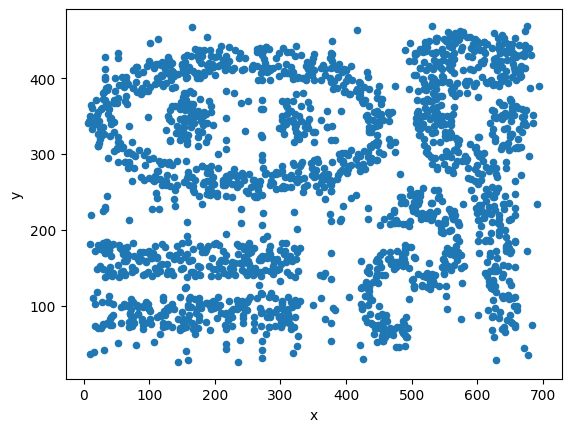

In [2]:
# Lectura del archivo chameleon
from pathlib import Path

import pandas as pd

chameleon_path = Path("chameleon.data")
if not chameleon_path.exists():
    chameleon_path = Path("Actividades/Taller Agrupación/chameleon.data")

data = pd.read_csv(chameleon_path, delimiter=" ", names=["x", "y"])
data.plot.scatter(x="x", y="y")

<Axes: xlabel='x', ylabel='y'>

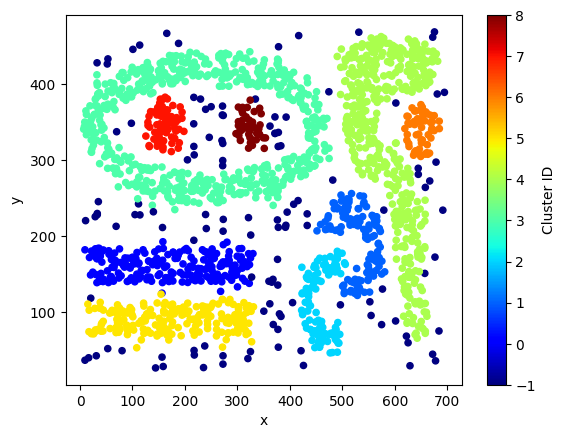

In [3]:
#Aplicacion del algoritmo DBSCAN
from sklearn.cluster import DBSCAN
import numpy as np

db = DBSCAN(eps=15.5, min_samples=5).fit(data)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = pd.DataFrame(db.labels_,columns=['Cluster ID'])
result = pd.concat((data,labels), axis=1)
result.plot.scatter(x='x',y='y',c='Cluster ID', colormap='jet')

### Ejercicio 1

Variar `epsilon` y `min_samples`. Analice los resultados.

Respuesta:

Para analizar el efecto de los parámetros de DBSCAN se prueban varias combinaciones de `eps` y `min_samples`. En cada caso se registra cuántos clusters se forman y cuántos puntos quedan marcados como ruido (`Cluster ID = -1`).

In [4]:
# Exploración de parámetros para DBSCAN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

parameter_grid = []
for eps in [10, 15.5, 20, 25]:
    for min_samples in [3, 5, 10]:
        parameter_grid.append((eps, min_samples))

summary_rows = []
dbscan_models = {}

for eps, min_samples in parameter_grid:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = model.fit_predict(data)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_count = int(np.sum(cluster_labels == -1))
    noise_percentage = noise_count / len(cluster_labels) * 100

    summary_rows.append({
        "eps": eps,
        "min_samples": min_samples,
        "clusters": n_clusters,
        "ruido": noise_count,
        "porcentaje_ruido": round(noise_percentage, 2),
    })
    dbscan_models[(eps, min_samples)] = cluster_labels

dbscan_summary = pd.DataFrame(summary_rows)
display(dbscan_summary)

,eps,min_samples,clusters,ruido,porcentaje_ruido
0,10.0,3,87,226,11.47
1,10.0,5,90,478,24.25
2,10.0,10,14,1788,90.72
3,15.5,3,16,82,4.16
4,15.5,5,9,125,6.34
5,15.5,10,39,345,17.50
6,20.0,3,11,37,1.88
7,20.0,5,5,77,3.91
8,20.0,10,7,109,5.53
9,25.0,3,5,13,0.66


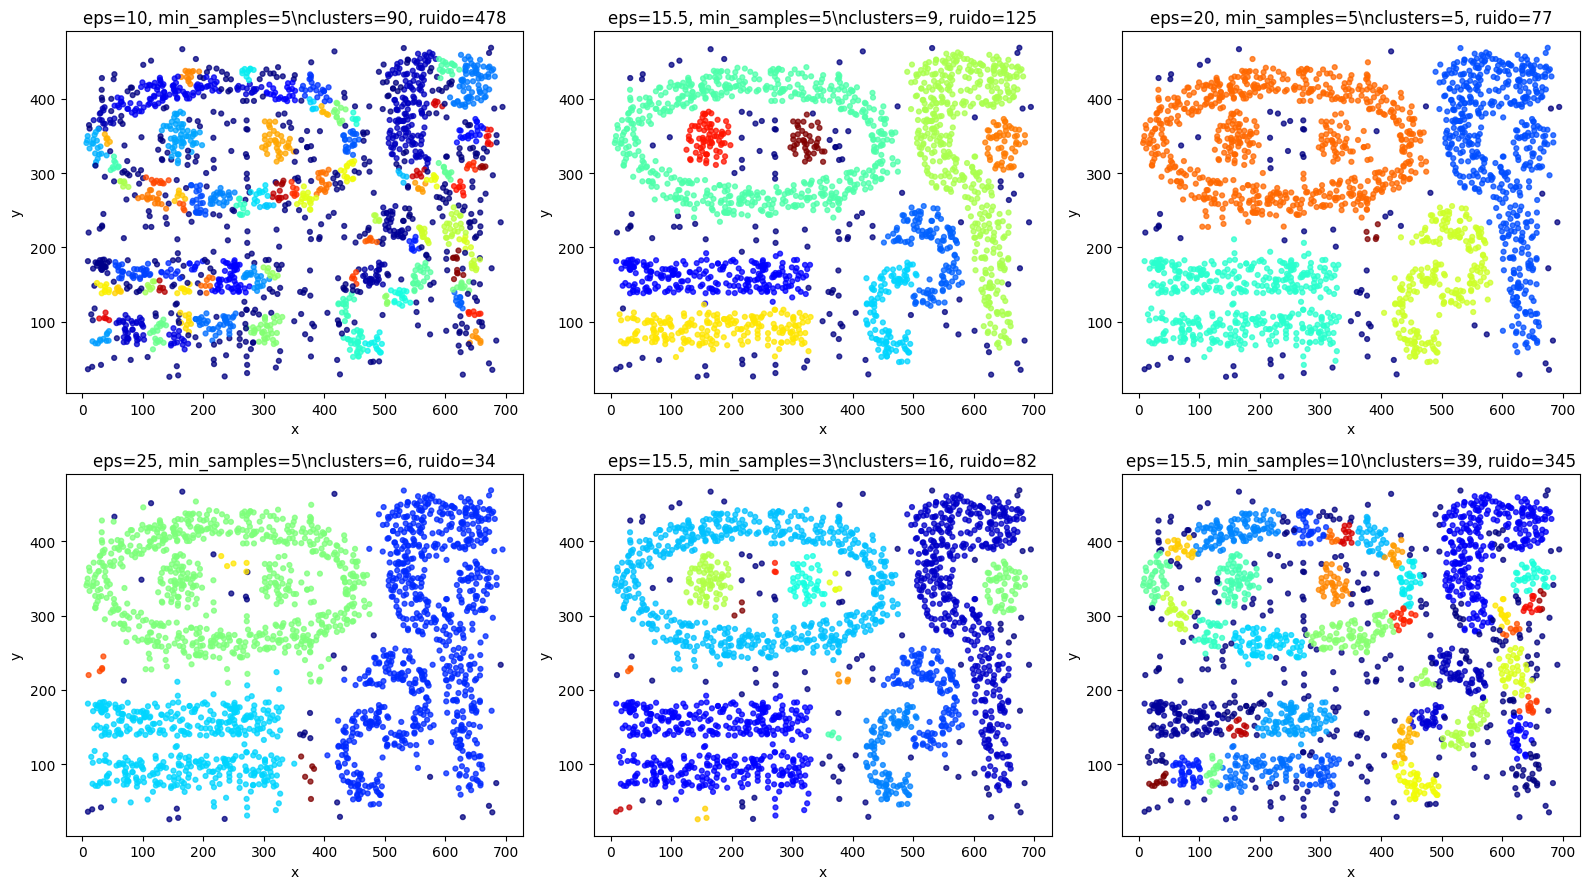

In [5]:
# Comparación visual de algunas combinaciones representativas
selected_parameters = [
    (10, 5),
    (15.5, 5),
    (20, 5),
    (25, 5),
    (15.5, 3),
    (15.5, 10),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (eps, min_samples) in zip(axes, selected_parameters):
    cluster_labels = dbscan_models[(eps, min_samples)]
    plot_data = data.copy()
    plot_data["Cluster ID"] = cluster_labels

    scatter = ax.scatter(
        plot_data["x"],
        plot_data["y"],
        c=plot_data["Cluster ID"],
        cmap="jet",
        s=12,
        alpha=0.75,
    )
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_count = int(np.sum(cluster_labels == -1))
    ax.set_title(f"eps={eps}, min_samples={min_samples}\\nclusters={n_clusters}, ruido={noise_count}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

Al variar `eps`, se observa que valores pequeños hacen que DBSCAN sea más estricto: se forman más grupos pequeños y aumenta la cantidad de puntos clasificados como ruido. Cuando `eps` aumenta, más puntos quedan conectados dentro de una misma vecindad y los clusters tienden a fusionarse.

Al variar `min_samples`, valores pequeños permiten formar clusters con menos puntos cercanos, por lo que aparecen más agrupaciones. Valores altos exigen vecindarios más densos y aumentan la cantidad de ruido, especialmente en zonas dispersas del conjunto.

La configuración inicial `eps=15.5` y `min_samples=5` funciona como punto intermedio: no es tan estricta como `eps=10`, pero tampoco fusiona tantos grupos como ocurre con valores de `eps` más grandes. Por eso es una configuración razonable para comparar con las demás.

### Ejercicio 2

Aplicar el algoritmo DBSCAN a otro conjunto de datos. Analice los resultados variando `epsilon` y `min_samples`.

Respuesta:

Para aplicar DBSCAN a otro conjunto de datos se crea un dataset sintético con `make_blobs`. Este conjunto tiene grupos compactos en dos dimensiones, lo que permite observar cómo cambian los clusters detectados al modificar `eps` y `min_samples`.

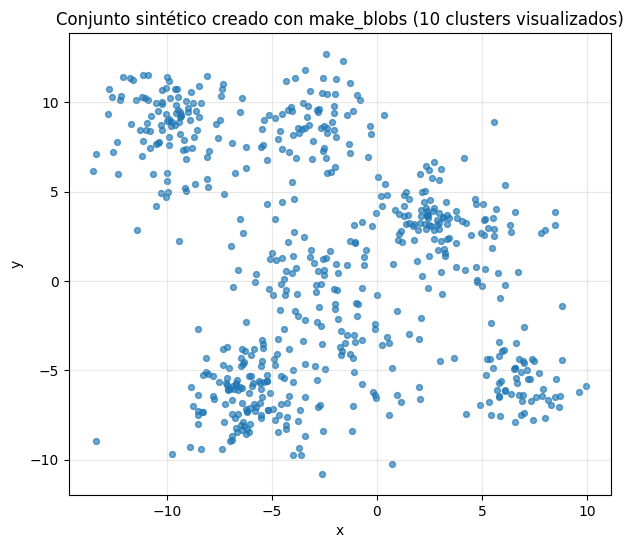

In [13]:
# Creación de un conjunto sintético con make_blobs
from sklearn.datasets import make_blobs
import pandas as pd
import matplotlib.pyplot as plt

X_blobs, y_blobs = make_blobs(
    n_samples=600,
    centers=10,
    cluster_std=[1.5, 1.8, 2.0, 2.2, 1.1, 1.2, 1.3, 1.4, 1.9, 2.1], # Aumentar los valores para mayor dispersión
    random_state=42,
)

blobs_data = pd.DataFrame(X_blobs, columns=["x", "y"])

plt.figure(figsize=(7, 6))
plt.scatter(blobs_data["x"], blobs_data["y"], s=18, alpha=0.65)
plt.title("Conjunto sintético creado con make_blobs (10 clusters visualizados)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

In [15]:
# Exploración de parámetros de DBSCAN sobre make_blobs
blobs_parameter_grid = []
for eps in [0.3, 0.5, 0.7, 1.0]:
    for min_samples in [3, 5, 10]:
        blobs_parameter_grid.append((eps, min_samples))

blobs_summary_rows = []
dbscan_blobs_models = {}

for eps, min_samples in blobs_parameter_grid:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = model.fit_predict(blobs_data)
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_count = int(np.sum(cluster_labels == -1))
    noise_percentage = noise_count / len(cluster_labels) * 100

    blobs_summary_rows.append({
        "eps": eps,
        "min_samples": min_samples,
        "clusters": n_clusters,
        "ruido": noise_count,
        "porcentaje_ruido": round(noise_percentage, 2),
    })
    dbscan_blobs_models[(eps, min_samples)] = cluster_labels

dbscan_blobs_summary = pd.DataFrame(blobs_summary_rows)
display(dbscan_blobs_summary)

,eps,min_samples,clusters,ruido,porcentaje_ruido
0,0.3,3,33,433,72.17
1,0.3,5,9,527,87.83
2,0.3,10,0,600,100.00
3,0.5,3,42,227,37.83
4,0.5,5,15,390,65.00
5,0.5,10,4,528,88.00
6,0.7,3,31,116,19.33
7,0.7,5,16,223,37.17
8,0.7,10,4,435,72.50
9,1.0,3,11,28,4.67


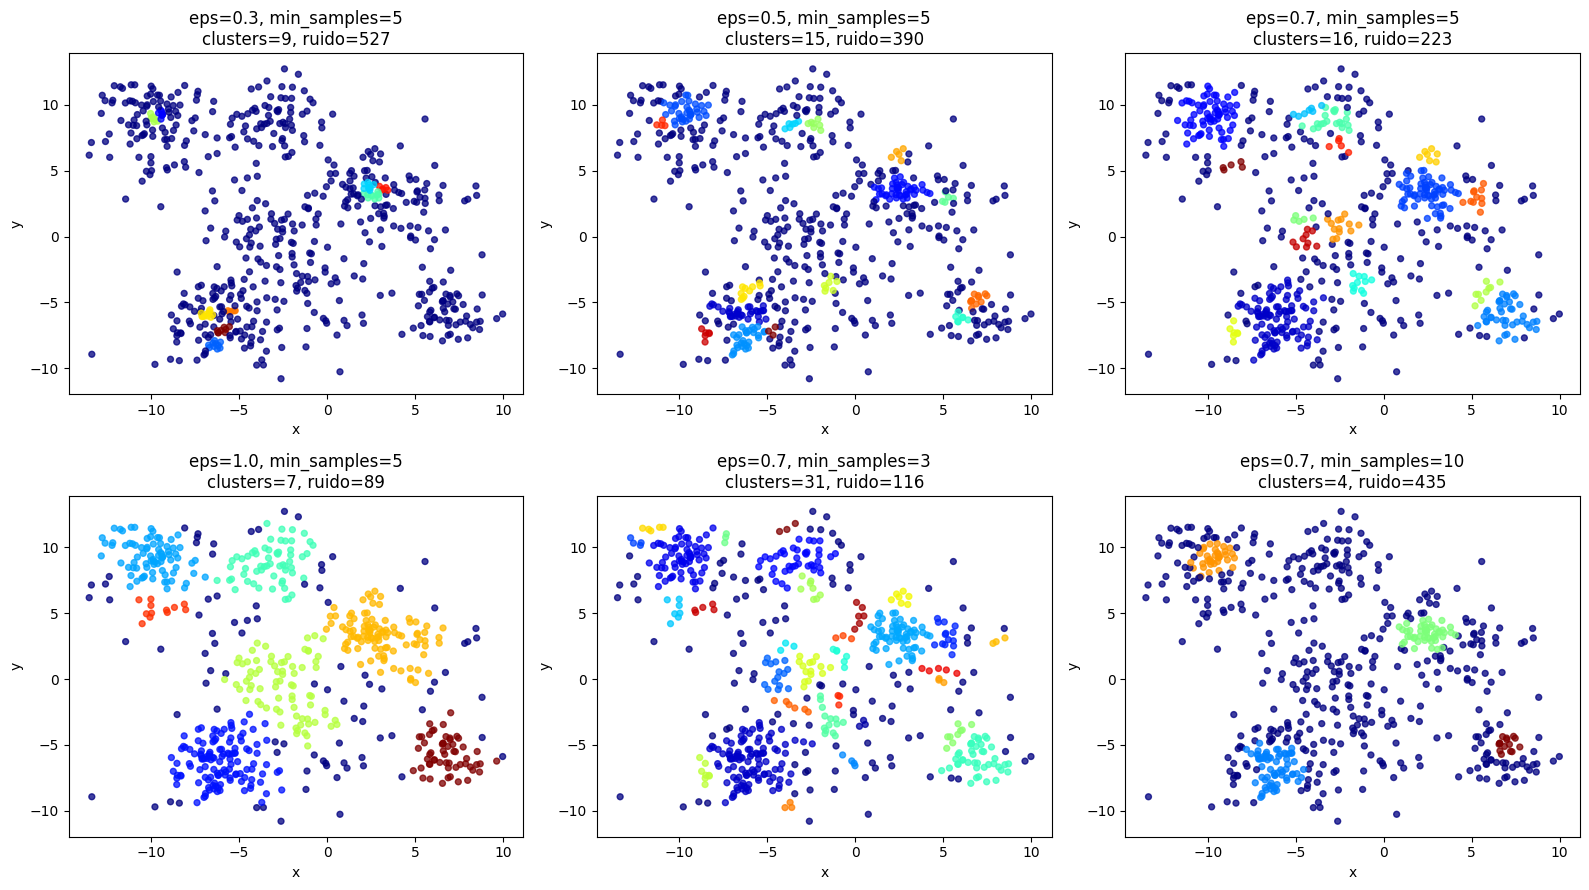

In [16]:
# Comparación visual de configuraciones representativas
selected_blob_parameters = [
    (0.3, 5),
    (0.5, 5),
    (0.7, 5),
    (1.0, 5),
    (0.7, 3),
    (0.7, 10),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, (eps, min_samples) in zip(axes, selected_blob_parameters):
    cluster_labels = dbscan_blobs_models[(eps, min_samples)]
    plot_data = blobs_data.copy()
    plot_data["Cluster ID"] = cluster_labels

    ax.scatter(
        plot_data["x"],
        plot_data["y"],
        c=plot_data["Cluster ID"],
        cmap="jet",
        s=18,
        alpha=0.75,
    )
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_count = int(np.sum(cluster_labels == -1))
    ax.set_title(f"eps={eps}, min_samples={min_samples}\nclusters={n_clusters}, ruido={noise_count}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

En el conjunto creado con `make_blobs`, DBSCAN puede identificar grupos compactos cuando `eps` es adecuado para la escala de los datos. Con `eps` muy pequeño, varios puntos quedan sin vecinos suficientes y se clasifican como ruido. Con `eps` más grande, los puntos se conectan con mayor facilidad y los clusters pueden crecer o fusionarse.

El parámetro `min_samples` controla la densidad mínima requerida para formar un cluster. Cuando `min_samples` es bajo, DBSCAN acepta regiones menos densas y reduce el ruido. Cuando `min_samples` es alto, el modelo exige más puntos cercanos y puede marcar como ruido puntos ubicados en los bordes de cada blob.

Para este dataset, una configuración intermedia como `eps=1.0` y `min_samples=5` porque ofrece una agrupación razonable: conserva la estructura general de los blobs sin fragmentar excesivamente los grupos ni fusionarlos demasiado.

## Gaussian Mixture Model (GMM)

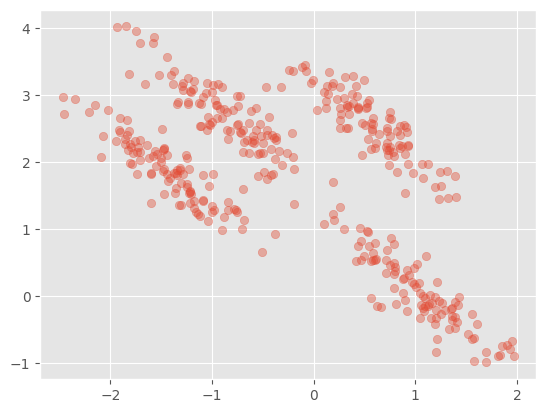

In [14]:
# Importamos librerías
import numpy as np
np.random.seed(0)
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")

# Creamos un dataset sintético de cuatro clusters no circulares
X, _ = make_blobs(n_samples=400, centers=4,
                       cluster_std=0.60, random_state=0)
rng = np.random.RandomState(13)
X=np.dot(X, rng.randn(2, 2))

plt.scatter(X[:,0],X[:,1],alpha=0.4)

In [16]:

from sklearn.mixture import GaussianMixture

model=GaussianMixture(n_components=4, covariance_type='full', random_state=40)
model.fit(X)

GaussianMixture(n_components=4, random_state=40)

Text(0.5, 1.0, 'GMM')

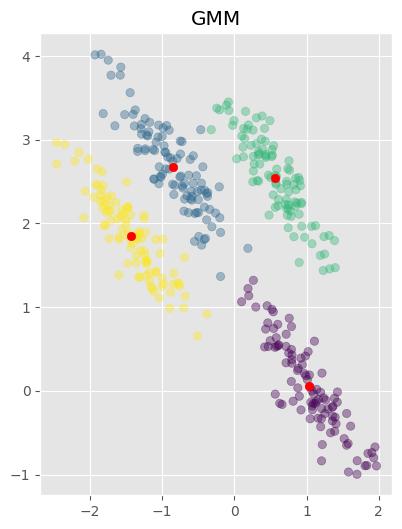

In [18]:
# Se dibujan los clusters obtenidos
plt.figure(figsize=(10,6))
pred2=model.predict(X)
plt.subplot(122)
plt.scatter(X[:,0],X[:,1],c=pred2,alpha=0.4)
plt.scatter(model.means_[:,0],model.means_[:,1],c="r")
plt.title("GMM")

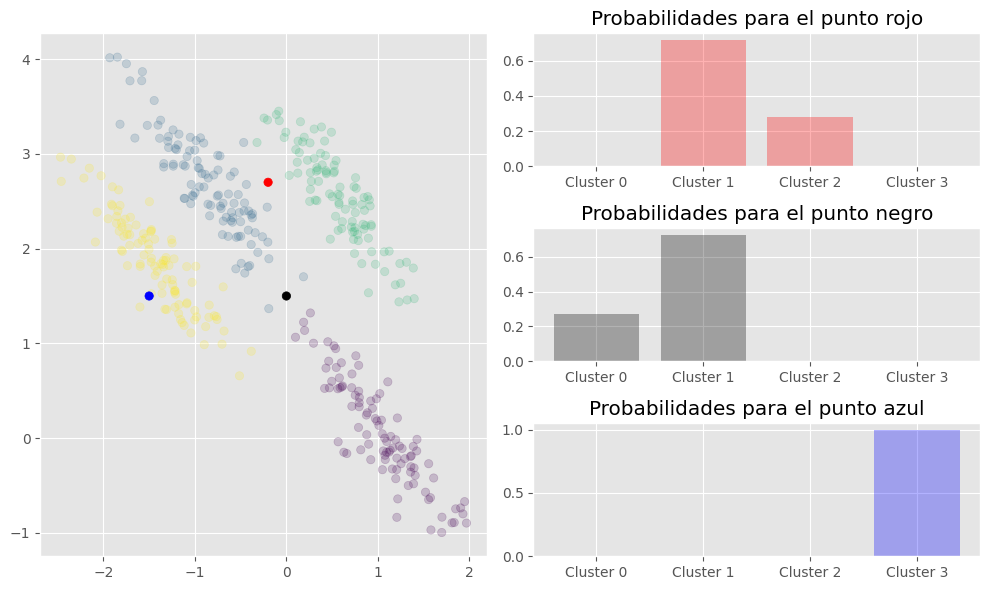

In [20]:
# En este ejmplo se visualizará la representación probabilística de tres puntos seleccionados:
# punto rojo, punto negro y punto azul (en la gráfica1). Se escogen estos puntos que se
# encuentran en la frontera con el fin de que pertenezcan a más de un cluster.

#Cambiar aqui la coordenada de los puntos y revisar el que se quiere evaluar

plt.figure(figsize=(10,6))
point=np.array([[-0.2,2.7],
                [0,1.5],
                [-1.5,1.5]])
probs=model.predict_proba(point)
plt.subplot(121)
plt.scatter(X[:,0],X[:,1],c=pred2,alpha=0.2)
plt.scatter(point[:,0],point[:,1],c=["r","k","b"])
plt.subplot(322)
plt.bar(["Cluster {}".format(i) for i in range(4)],probs[0].flatten(), color="r", alpha=0.3)
plt.title("Probabilidades para el punto rojo")
plt.subplot(324)
plt.bar(["Cluster {}".format(i) for i in range(4)],probs[1].flatten(), color="k", alpha=0.3)
plt.title("Probabilidades para el punto negro")
plt.subplot(326)
plt.bar(["Cluster {}".format(i) for i in range(4)],probs[2].flatten(), color="b", alpha=0.3)
plt.title("Probabilidades para el punto azul")
plt.tight_layout()

### Ejercicio 2

¿Cuáles serían las probabilidades para el punto `(-1.5, 1.5)`?

Respuesta:

Para responder se usa el modelo GMM ya entrenado y se calcula la probabilidad posterior de pertenencia del punto `(-1.5, 1.5)` a cada componente gaussiana.

In [27]:
# Probabilidades de pertenencia para el punto (-1.5, 1.5)
gmm_point = np.array([[-1.5, 1.5]])
gmm_probabilities = model.predict_proba(gmm_point).flatten()
gmm_cluster = model.predict(gmm_point)[0]

gmm_probability_table = pd.DataFrame({
    "Cluster": [f"Cluster {i}" for i in range(len(gmm_probabilities))],
    "Probabilidad": gmm_probabilities,
})

display(gmm_probability_table)
print(f"Cluster asignado: Cluster {gmm_cluster}")

,Cluster,Probabilidad
0,Cluster 0,1.884532e-14
1,Cluster 1,9.285575e-12
2,Cluster 2,8.272861e-49
3,Cluster 3,1.000000e+00


Cluster asignado: Cluster 3


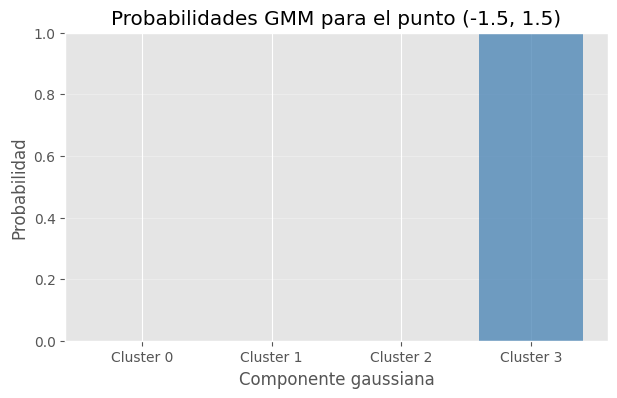

In [28]:
# Visualización de las probabilidades del punto evaluado
plt.figure(figsize=(7, 4))
plt.bar(gmm_probability_table["Cluster"], gmm_probability_table["Probabilidad"], color="steelblue", alpha=0.75)
plt.title("Probabilidades GMM para el punto (-1.5, 1.5)")
plt.xlabel("Componente gaussiana")
plt.ylabel("Probabilidad")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)
plt.show()

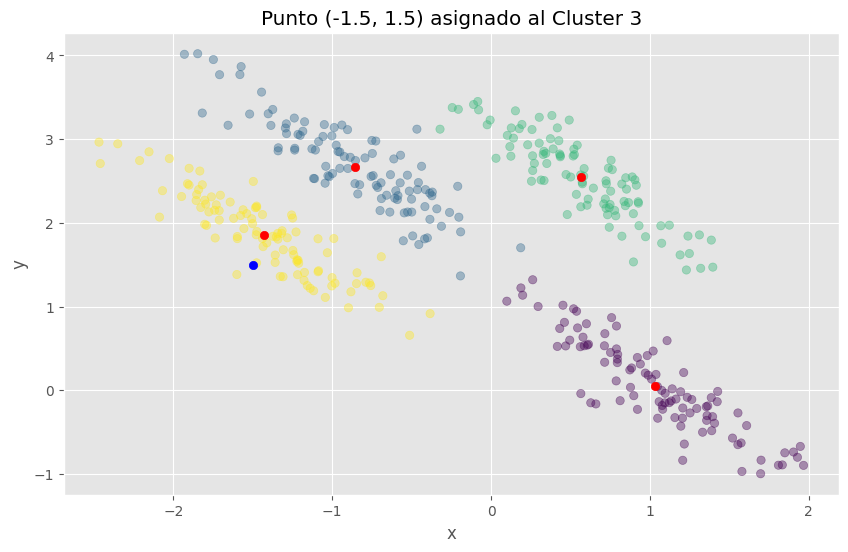

In [34]:
# Ubicación del punto evaluado dentro del cluster asignado por GMM
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=pred2, alpha=0.4)
plt.scatter(model.means_[:, 0], model.means_[:, 1], c="r")
plt.scatter(gmm_point[:, 0], gmm_point[:, 1], c="b")
plt.title(f"Punto (-1.5, 1.5) asignado al Cluster {gmm_cluster}")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

La probabilidad más alta indica el componente gaussiano al que el modelo asigna el punto `(-1.5, 1.5)`. Si una probabilidad domina claramente, el punto pertenece de forma más definida a ese cluster. Si dos o más probabilidades son parecidas, el punto se encuentra cerca de una zona de frontera entre componentes.

### Ejercicio 3

Ejecutar el algoritmo K-means con este conjunto de datos. Comparar visualmente los resultados de los dos modelos.

Respuesta:

Se entrena K-means sobre el mismo conjunto de datos `X` usado por GMM. Como el dataset fue creado con cuatro grupos, se usa `n_clusters=4` para que la comparación visual sea directa.

In [44]:
# Aplicación de K-means sobre el conjunto usado por GMM
from sklearn.cluster import KMeans

kmeans_model = KMeans(n_clusters=4, n_init=10, random_state=2)
kmeans_labels = kmeans_model.fit_predict(X)

kmeans_gmm_comparison = pd.DataFrame({
    "x": X[:, 0],
    "y": X[:, 1],
    "cluster_gmm": pred2,
    "cluster_kmeans": kmeans_labels,
})

display(kmeans_gmm_comparison.head())

,x,y,cluster_gmm,cluster_kmeans
0,-0.466891,3.119969,1,2
1,1.809786,-0.894205,0,3
2,1.929417,-0.799470,0,3
3,-0.692774,2.479103,1,2
4,1.700245,-0.833930,0,3


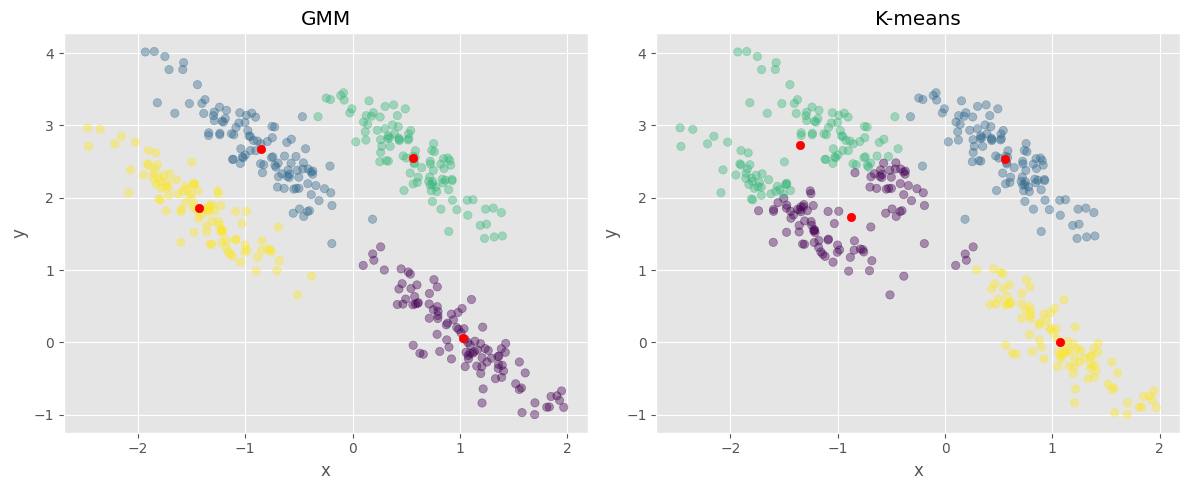

In [45]:
# Comparación visual entre GMM y K-means
plt.figure(figsize=(12, 5))

plt.subplot(121)
plt.scatter(X[:, 0], X[:, 1], c=pred2, alpha=0.4)
plt.scatter(model.means_[:, 0], model.means_[:, 1], c="r")
plt.title("GMM")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(122)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, alpha=0.4)
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], c="r")
plt.title("K-means")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

GMM y K-means producen agrupaciones parecidas cuando los grupos están bien separados, pero no optimizan el mismo criterio. K-means asigna cada punto al centroide más cercano y tiende a formar regiones más rígidas. GMM modela cada grupo como una distribución gaussiana y puede adaptarse mejor a clusters alargados o con orientación diagonal, como ocurre en este conjunto transformado.

Visualmente, GMM suele representar mejor la forma no circular de los grupos, mientras que K-means puede cortar algunos puntos de frontera de manera más rígida porque depende principalmente de la distancia al centroide.

### Ejercicio 4

Aplicar DBSCAN al conjunto de datos.

Respuesta:

Se aplica DBSCAN al mismo conjunto `X` usado en GMM y K-means. Como DBSCAN depende de la densidad, se prueban varios valores de `eps` y `min_samples` para observar cuántos clusters aparecen y cuántos puntos quedan como ruido.

In [47]:
# Exploración de parámetros DBSCAN sobre el conjunto usado por GMM
dbscan_gmm_parameter_grid = []
for eps in [0.3, 0.5, 0.7, 1.0]:
    for min_samples in [3, 5, 10]:
        dbscan_gmm_parameter_grid.append((eps, min_samples))

dbscan_gmm_summary_rows = []
dbscan_gmm_models = {}

for eps, min_samples in dbscan_gmm_parameter_grid:
    dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan_model.fit_predict(X)
    n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    noise_count = int(np.sum(dbscan_labels == -1))
    noise_percentage = noise_count / len(dbscan_labels) * 100

    dbscan_gmm_summary_rows.append({
        "eps": eps,
        "min_samples": min_samples,
        "clusters": n_clusters,
        "ruido": noise_count,
        "porcentaje_ruido": round(noise_percentage, 2),
    })
    dbscan_gmm_models[(eps, min_samples)] = dbscan_labels

dbscan_gmm_dataset_summary = pd.DataFrame(dbscan_gmm_summary_rows)
display(dbscan_gmm_dataset_summary)

,eps,min_samples,clusters,ruido,porcentaje_ruido
0,0.3,3,2,4,1.0
1,0.3,5,4,4,1.0
2,0.3,10,5,26,6.5
3,0.5,3,1,0,0.0
4,0.5,5,1,0,0.0
5,0.5,10,2,2,0.5
6,0.7,3,1,0,0.0
7,0.7,5,1,0,0.0
8,0.7,10,1,0,0.0
9,1.0,3,1,0,0.0


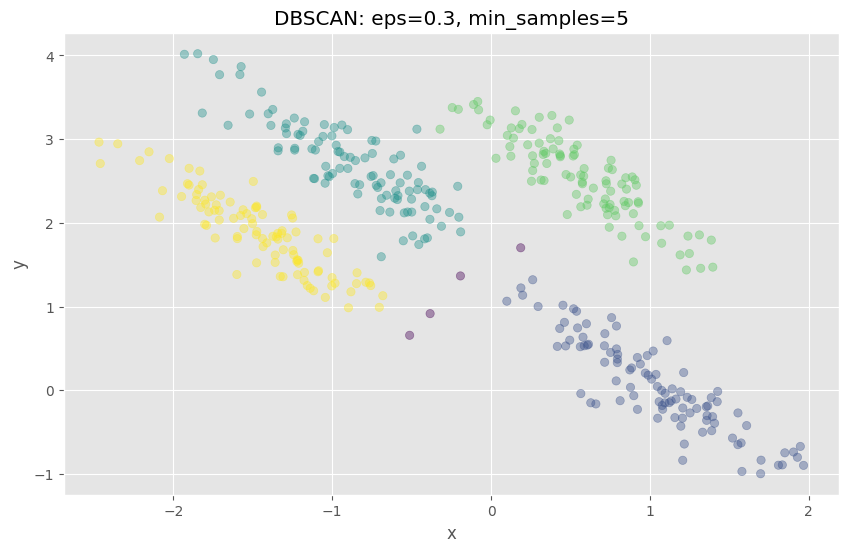

Clusters encontrados: 4
Puntos clasificados como ruido: 4


In [51]:
# Aplicación final de DBSCAN con una configuración intermedia
dbscan_selected_eps = 0.3
dbscan_selected_min_samples = 5
dbscan_final = DBSCAN(eps=dbscan_selected_eps, min_samples=dbscan_selected_min_samples)
dbscan_labels = dbscan_final.fit_predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, alpha=0.4)
plt.title(f"DBSCAN: eps={dbscan_selected_eps}, min_samples={dbscan_selected_min_samples}")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

print("Clusters encontrados:", len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0))
print("Puntos clasificados como ruido:", int(np.sum(dbscan_labels == -1)))

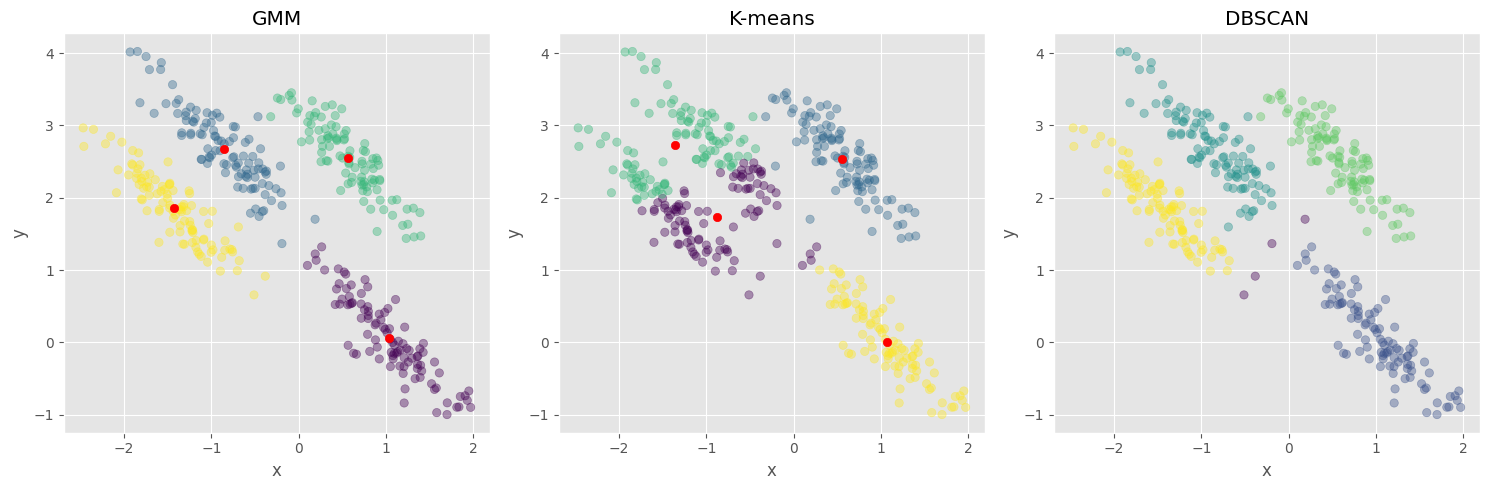

In [52]:
# Comparación visual de GMM, K-means y DBSCAN
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.scatter(X[:, 0], X[:, 1], c=pred2, alpha=0.4)
plt.scatter(model.means_[:, 0], model.means_[:, 1], c="r")
plt.title("GMM")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(132)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, alpha=0.4)
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], c="r")
plt.title("K-means")
plt.xlabel("x")
plt.ylabel("y")

plt.subplot(133)
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, alpha=0.4)
plt.title("DBSCAN")
plt.xlabel("x")
plt.ylabel("y")

plt.tight_layout()
plt.show()

DBSCAN no necesita fijar previamente el número de clusters, pero sí depende bastante de `eps` y `min_samples`. En este conjunto, si `eps` es pequeño, varios puntos quedan marcados como ruido o se fragmentan los grupos. Si `eps` aumenta, los grupos se conectan más fácilmente.

Comparado con GMM y K-means, DBSCAN puede detectar puntos aislados como ruido, lo cual los otros dos modelos no hacen. Sin embargo, en este dataset transformado los clusters tienen forma alargada y densidades variables, por lo que DBSCAN puede ser más sensible a la elección de parámetros.

### Ejercicio 5 - Conclusiones

Explicar y analizar los resultados de aplicar GMM, K-means y DBSCAN.

Respuesta:

Los tres algoritmos permiten agrupar el mismo conjunto de datos, pero cada uno parte de una idea diferente. Por eso los resultados no tienen que coincidir exactamente.

In [ ]:
# Resumen conceptual de los tres métodos
comparison_summary = pd.DataFrame({
    "Modelo": ["GMM", "K-means", "DBSCAN"],
    "Idea principal": [
        "Modela los datos como mezcla de distribuciones gaussianas",
        "Asigna puntos al centroide más cercano",
        "Forma grupos a partir de regiones densas",
    ],
    "Parámetro clave": [
        "n_components",
        "n_clusters",
        "eps y min_samples",
    ],
    "Ventaja": [
        "Representa clusters alargados y entrega probabilidades",
        "Es simple, rápido y fácil de interpretar",
        "Detecta ruido y no exige definir el número de clusters",
    ],
    "Limitación": [
        "Requiere elegir el número de componentes",
        "Tiende a formar grupos rígidos alrededor de centroides",
        "Es sensible a la escala y a la elección de eps",
    ],
})

display(comparison_summary)

**Conclusión general**

- **GMM** fue el modelo más flexible para este conjunto, porque los datos fueron transformados y los grupos no son perfectamente circulares. Además, permite calcular probabilidades de pertenencia, como se hizo con el punto `(-1.5, 1.5)`.
- **K-means** produjo una agrupación comparable, pero más rígida. Este método funciona bien cuando los grupos son compactos y aproximadamente circulares, pero puede separar peor puntos en zonas de frontera o clusters alargados.
- **DBSCAN** permitió analizar los datos desde la densidad. Su ventaja es que puede identificar ruido y no necesita fijar previamente el número de clusters. Sin embargo, el resultado cambia bastante al modificar `eps` y `min_samples`.
- En este caso, **GMM** parece el más adecuado para representar la forma de los grupos, **K-means** sirve como comparación simple basada en centroides y **DBSCAN** aporta una perspectiva adicional al detectar agrupaciones densas y posibles puntos atípicos.

no existe un único algoritmo mejor para todos los casos. La elección depende de la forma de los datos, de si se necesita detectar ruido y de si se quiere una asignación rígida o probabilística.

## Referencias

[1] TAN y otros. *Introduction to Data Mining* (segunda edición).

[2] George Karypis, Eui-Hong Han, and Vipin Kumar. *CHAMELEON: A Hierarchical Clustering Algorithm Using Dynamic Modeling*. IEEE Computer 32(8): 68-75, 1999.
